# Graph Analysis - Neo4j + PageRank + Communities

## Part 1: Load Graph into Neo4j

In [5]:
from neo4j import GraphDatabase
from dotenv import load_dotenv, find_dotenv
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import os
import pandas as pd

In [6]:
load_dotenv(find_dotenv(), override=True)

URI = os.getenv("NEO4J_URI")
AUTH = (os.getenv("NEO4J_USER"), os.getenv("NEO4J_PASSWORD"))

driver = GraphDatabase.driver(URI, auth=AUTH)
driver.verify_connectivity()
print("Connected!")

Connected!


## Part 2: Verify Graph

In [7]:
df = pd.read_csv("../data/processed/neo4j_edges.csv")
print(df.shape)
print(df.head())

(50000, 4)
                    ingredient_name product_id  \
0                      water (aqua)    P504322   
1                dipropylene glycol    P504322   
2  peg-6 caprylic/capric glycerides    P504322   
3                          glycerin    P504322   
4                      2-hexanediol    P504322   

                     product_name primary_category  
0  Gentle Hydra-Gel Face Cleanser         Skincare  
1  Gentle Hydra-Gel Face Cleanser         Skincare  
2  Gentle Hydra-Gel Face Cleanser         Skincare  
3  Gentle Hydra-Gel Face Cleanser         Skincare  
4  Gentle Hydra-Gel Face Cleanser         Skincare  


In [8]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("Database cleared.")

Database cleared.


In [9]:
def load_batch(tx, batch):
    tx.run("""
        UNWIND $batch AS row
        MERGE (i:Ingredient {name: row.ingredient_name})
        MERGE (p:Product {
            id: row.product_id,
            name: row.product_name,
            category: row.primary_category
        })
        MERGE (i)-[:FOUND_IN]->(p)
    """, batch=batch)

batch_size = 10000
records = df.to_dict("records")

with driver.session() as session:
    for i in range(0, len(records), batch_size):
        batch = records[i:i+batch_size]
        session.execute_write(load_batch, batch)
        print(f"Loaded {min(i+batch_size, len(records))} / {len(records)}")

print("Done loading graph!")

Loaded 10000 / 50000
Loaded 20000 / 50000
Loaded 30000 / 50000
Loaded 40000 / 50000
Loaded 50000 / 50000
Done loading graph!


In [10]:
with driver.session() as session:
    result = session.run("""
        MATCH (i:Ingredient)
        WITH count(i) AS ingredient_count
        MATCH (p:Product)
        RETURN ingredient_count, count(p) AS product_count
    """)
    for row in result:
        print(f"Ingredient nodes: {row['ingredient_count']}")
        print(f"Product nodes:    {row['product_count']}")

Ingredient nodes: 6347
Product nodes:    1288


In [11]:
with driver.session() as session:
    result = session.run("""
        MATCH (i:Ingredient)-[:FOUND_IN]->(p:Product)
        RETURN i.name AS ingredient, COUNT(p) AS product_count
        ORDER BY product_count DESC
        LIMIT 20
    """)
    df_central = pd.DataFrame([dict(r) for r in result])

print(df_central)

                      ingredient  product_count
0                       glycerin           1005
1                 phenoxyethanol            645
2                butylene glycol            624
3                    citric acid            523
4             sodium hyaluronate            502
5                     tocopherol            497
6                    propanediol            486
7                    xanthan gum            462
8                caprylyl glycol            447
9             ethylhexylglycerin            443
10               sodium benzoate            400
11  caprylic/capric triglyceride            387
12              sodium hydroxide            377
13                 disodium edta            372
14             potassium sorbate            372
15            tocopheryl acetate            361
16                   dimethicone            341
17                         water            340
18                      limonene            305
19                      squalane        

In [12]:
with driver.session() as session:
    result = session.run("""
        MATCH (i1:Ingredient)-[:FOUND_IN]->(p:Product)<-[:FOUND_IN]-(i2:Ingredient)
        WHERE i1.name < i2.name
        RETURN i1.name AS ingredient_1, i2.name AS ingredient_2, 
               COUNT(p) AS co_occurrences
        ORDER BY co_occurrences DESC
        LIMIT 20
    """)
    df_cooccur = pd.DataFrame([dict(r) for r in result])

print(df_cooccur)

                    ingredient_1        ingredient_2  co_occurrences
0                       glycerin      phenoxyethanol             568
1                butylene glycol            glycerin             557
2                    citric acid            glycerin             481
3                       glycerin  sodium hyaluronate             449
4                       glycerin         xanthan gum             438
5                       glycerin         propanediol             436
6                       glycerin          tocopherol             411
7             ethylhexylglycerin            glycerin             405
8                caprylyl glycol            glycerin             396
9                       glycerin     sodium benzoate             366
10               butylene glycol      phenoxyethanol             362
11                      glycerin    sodium hydroxide             350
12                 disodium edta            glycerin             345
13                      glycerin  

In [13]:
# Pull edges from Neo4j
with driver.session() as session:
    result = session.run("""
        MATCH (i:Ingredient)-[:FOUND_IN]->(p:Product)
        RETURN i.name AS ingredient, p.id AS product_id
    """)
    edges = pd.DataFrame([dict(r) for r in result])

print(f"Loaded {len(edges)} edges")

Loaded 50000 edges


## Part 3: Co-occurrence Graph (NetworkX)

In [14]:
product_ingredients = edges.groupby("product_id")["ingredient"].apply(list)

# Build co-occurrence graph
G = nx.Graph()

for product_id, ingredients in product_ingredients.items():
    for i in range(len(ingredients)):
        for j in range(i + 1, len(ingredients)):
            ing1, ing2 = ingredients[i], ingredients[j]
            if G.has_edge(ing1, ing2):
                G[ing1][ing2]["weight"] += 1
            else:
                G.add_edge(ing1, ing2, weight=1)

print(f"Nodes (ingredients)    : {G.number_of_nodes():,}")
print(f"Edges (co-occurrences) : {G.number_of_edges():,}")

Nodes (ingredients)    : 6,339
Edges (co-occurrences) : 568,225


## Part 4: PageRank Algorithm

Running PageRank...

Top 20 Most Influential Ingredients (PageRank):
                       ingredient  pagerank_score
54                       glycerin        0.013060
17                butylene glycol        0.008744
27                 phenoxyethanol        0.008708
25                    citric acid        0.007479
124                    tocopherol        0.007270
88             sodium hyaluronate        0.007037
494                   propanediol        0.006766
170                   xanthan gum        0.006765
108               caprylyl glycol        0.006415
341            ethylhexylglycerin        0.006084
115  caprylic/capric triglyceride        0.005810
16                sodium benzoate        0.005699
19              potassium sorbate        0.005542
55             tocopheryl acetate        0.005454
72                    dimethicone        0.005323
58                  disodium edta        0.005257
13               sodium hydroxide        0.005133
175                      squala

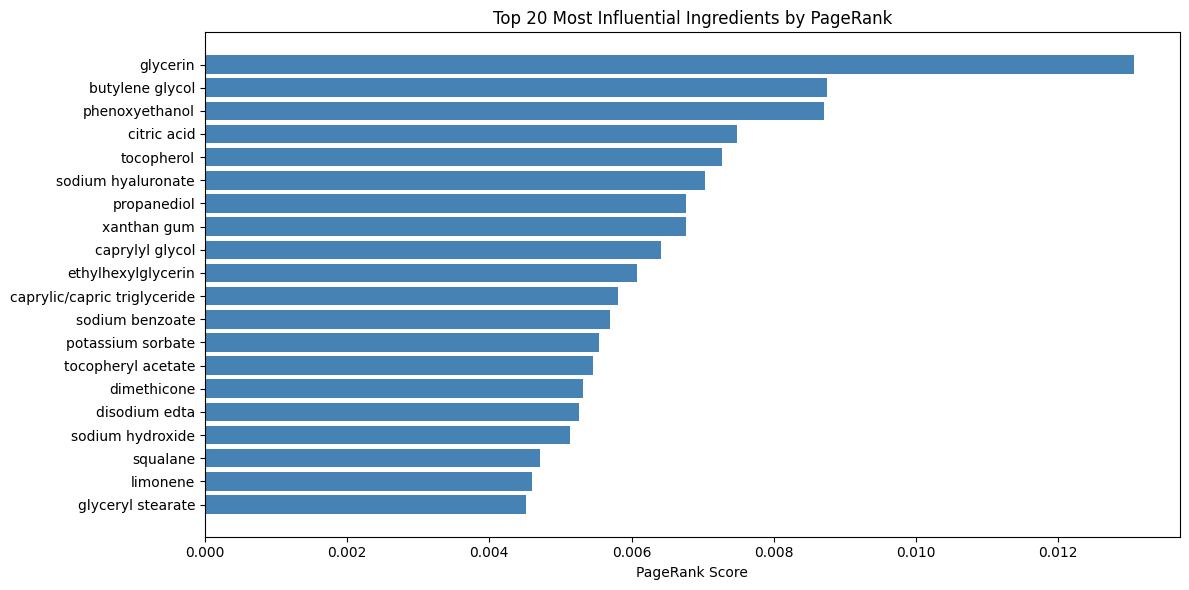

In [15]:
print("Running PageRank...")

pagerank_scores = nx.pagerank(G, weight="weight")

df_pagerank = pd.DataFrame([
    {"ingredient": k, "pagerank_score": v}
    for k, v in pagerank_scores.items()
]).sort_values("pagerank_score", ascending=False)

print("\nTop 20 Most Influential Ingredients (PageRank):")
print(df_pagerank.head(20).to_string())

plt.figure(figsize=(12, 6))
top20 = df_pagerank.head(20)
plt.barh(top20["ingredient"][::-1], top20["pagerank_score"][::-1], color="steelblue")
plt.xlabel("PageRank Score")
plt.title("Top 20 Most Influential Ingredients by PageRank")
plt.tight_layout()
plt.show()

## Part 5: Louvain Community Detection

In [16]:
print("Running Louvain Community Detection...")

partition = community_louvain.best_partition(G, weight="weight")

df_communities = pd.DataFrame([
    {"ingredient": k, "community": v}
    for k, v in partition.items()
])

df_communities = df_communities.merge(df_pagerank, on="ingredient")

print(f"Detected {df_communities['community'].nunique()} communities")

print("\nTop 3 ingredients per community (by PageRank):")
top_per_community = (
    df_communities
    .sort_values("pagerank_score", ascending=False)
    .groupby("community")
    .head(3)
    .sort_values(["community", "pagerank_score"], ascending=[True, False])
)
print(top_per_community.to_string())

Running Louvain Community Detection...
Detected 24 communities

Top 3 ingredients per community (by PageRank):
                                                          ingredient  community  pagerank_score
17                                                   butylene glycol          0        0.008744
88                                                sodium hyaluronate          0        0.007037
55                                                tocopheryl acetate          0        0.005454
27                                                    phenoxyethanol          1        0.008708
25                                                       citric acid          1        0.007479
16                                                   sodium benzoate          1        0.005699
262                                                    cetyl alcohol          2        0.002756
126                                                     maltodextrin          2        0.002370
281                      

/var/folders/f5/qyqh2h6126dgkdck1p6qkl3h0000gn/T/ipykernel_31718/3632802405.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(unique_communities))


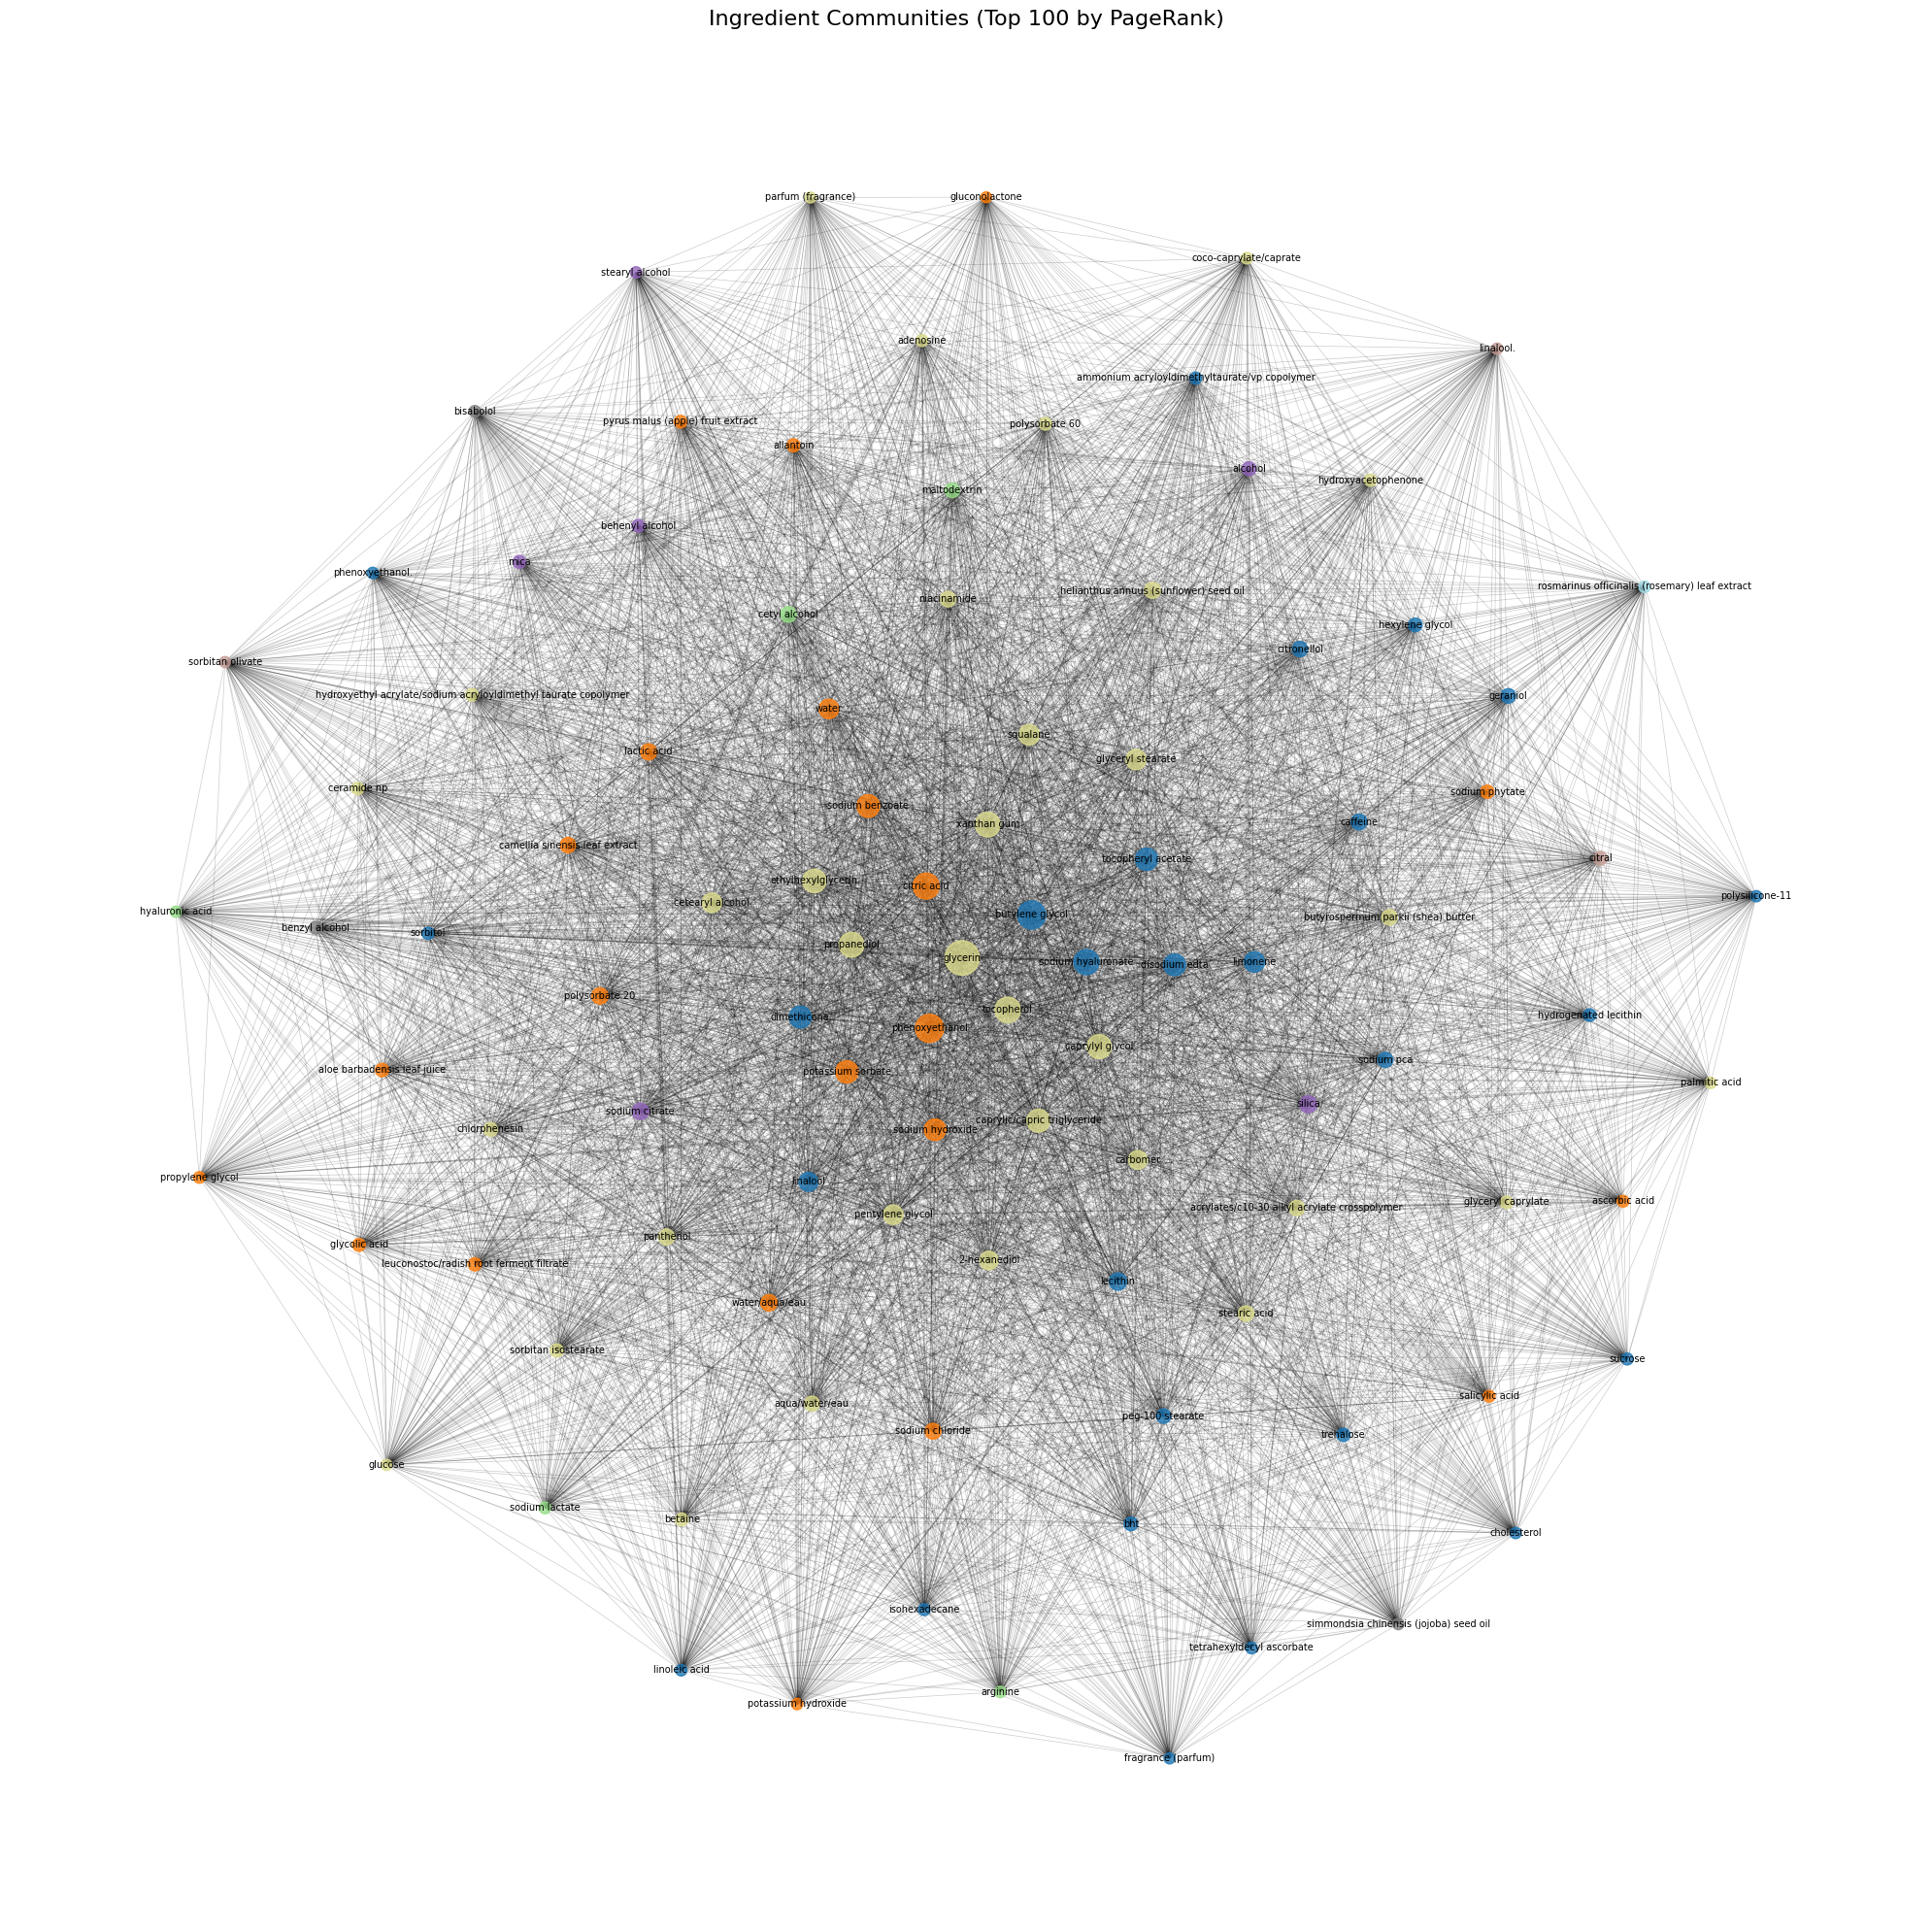

In [17]:
top_nodes = df_pagerank.head(100)["ingredient"].tolist()
subgraph = G.subgraph(top_nodes)

communities = [partition.get(node, 0) for node in subgraph.nodes()]
unique_communities = list(set(communities))
color_map = plt.cm.get_cmap("tab20", len(unique_communities))
node_colors = [color_map(unique_communities.index(c)) for c in communities]
node_sizes = [pagerank_scores.get(node, 0.001) * 50000 for node in subgraph.nodes()]

plt.figure(figsize=(20, 20))
pos = nx.spring_layout(subgraph, k=2, seed=42)
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, width=0.5)
nx.draw_networkx_labels(subgraph, pos, font_size=7)
plt.title("Ingredient Communities (Top 100 by PageRank)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
def write_pagerank(tx, batch):
    tx.run("""
        UNWIND $batch AS row
        MATCH (i:Ingredient {name: row.ingredient})
        SET i.pagerank = row.pagerank_score,
            i.community = row.community
    """, batch=batch)

df_final = df_pagerank.merge(
    df_communities[["ingredient", "community"]], on="ingredient"
)
records = df_final.to_dict("records")

with driver.session() as session:
    for i in range(0, len(records), 1000):
        batch = records[i:i+500]
        session.execute_write(write_pagerank, batch)
        print(f"Written {min(i+500, len(records))} / {len(records)}")

print("PageRank + Communities written back to Neo4j!")

Written 500 / 6339
Written 1500 / 6339
Written 2500 / 6339
Written 3500 / 6339
Written 4500 / 6339
Written 5500 / 6339
Written 6339 / 6339
PageRank + Communities written back to Neo4j!


Community Summary:
    community                                                  top_ingredient  size
8           8                                                        glycerin  1453
1           1                                                  phenoxyethanol  1055
4           4                                                          citral   905
0           0                                                 butylene glycol   727
3           3                                                          silica   532
6           6                                                  benzyl alcohol   468
2           2                                                   cetyl alcohol   407
9           9                  rosmarinus officinalis (rosemary) leaf extract   215
5           5                                    glycerin (skin-replenishing)   195
14         14                                                       vitamin c   180
11         11                               olea europaea

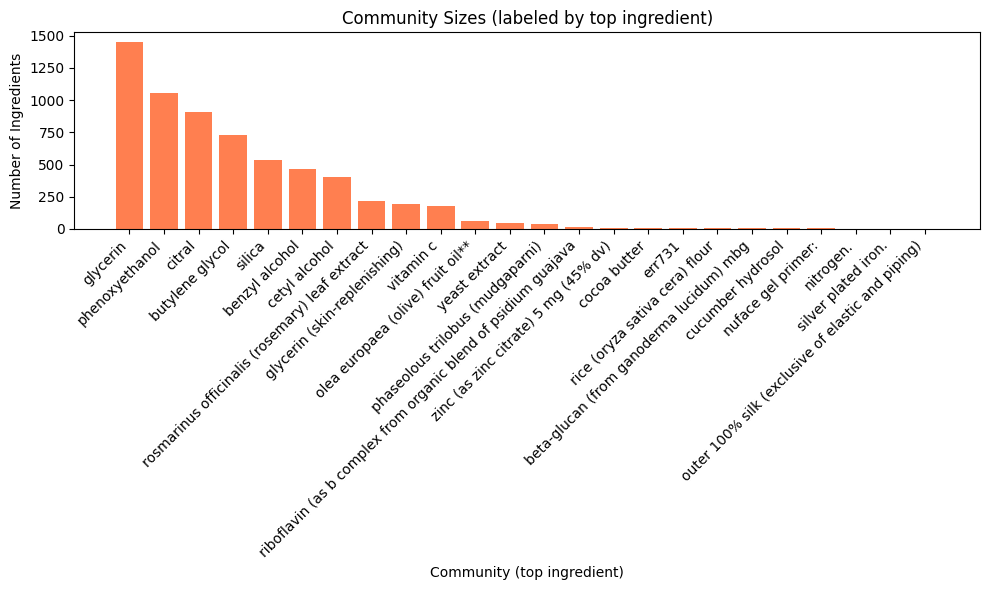

In [21]:
community_labels = (
    df_communities
    .sort_values("pagerank_score", ascending=False)
    .groupby("community")
    .first()
    .reset_index()[["community", "ingredient"]]
    .rename(columns={"ingredient": "top_ingredient"})
)

community_size = df_communities.groupby("community").size().reset_index(name="size")
community_summary = community_labels.merge(community_size, on="community")
community_summary = community_summary.sort_values("size", ascending=False)

print("Community Summary:")
print(community_summary.to_string())

plt.figure(figsize=(10, 6))
plt.bar(community_summary["top_ingredient"],
        community_summary["size"], color="coral")
plt.xticks(rotation=45, ha="right")
plt.title("Community Sizes (labeled by top ingredient)")
plt.xlabel("Community (top ingredient)")
plt.ylabel("Number of Ingredients")
plt.tight_layout()
plt.show()